In [1]:
# !python -m pip install ipywidgets

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

from IPython.display import clear_output

from sklearn.linear_model import LinearRegression
import geopandas as gpd
from libpysal.weights import Queen
from spopt.region.skater import Skater
from sklearn.preprocessing import StandardScaler

import hdbscan
import matplotlib.pyplot as plt
import seaborn as sns

import folium
from folium.plugins import HeatMap, MarkerCluster

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors

import seaborn as sns
from ipywidgets import interact, widgets

## Fill in missing values

To fill the missing values, we are using interpolation as the scheme of the data that we are working with has edge NaN values. In addition, in some places interpolation fails as well where we take the mean of the whole series and place it in. 

To comply with the input format for the algorithm, we will melt the data into longer format and then bring it back to its original form, once all the missing values are sorted. sorted. 

In [3]:
from helper_functions import combine_csvs

In [4]:
directory = r"D:\CDR_study_areas\VHI\median_VHI"
output_file = "combine_median_VHI.csv"
# lsit items in the directory
# combine_csvs(directory, output_file)


In [5]:
import os

In [6]:
# i want to combine climaete_csv to median VHI csv with fid and year
df = pd.read_csv(r"D:\CDR_study_areas\output\climate_vars_2021_2024.csv")
vhi_df = pd.read_csv(os.path.join(directory, output_file))
df = df.merge(vhi_df, on=['fid', 'year', 'month', 'season'], how='left')
df

,precip_max,NDVI,LST,month,season,year,fid,COMMUNE,DEPARTEMEN,REGION,VHI_M
0,84.360580,0.247579,36.670000,6,Wet,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.785
1,96.560768,0.405126,35.765968,10,Wet,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.695
2,0.499313,0.189875,45.970000,4,Dry,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.690
3,0.000000,0.185850,42.800000,3,Dry,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.630
4,207.771942,0.395683,32.421573,7,Wet,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.620
...,...,...,...,...,...,...,...,...,...,...,...
26539,489.136200,0.292800,26.950000,7,Wet,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.660
26540,597.792786,0.479265,25.640000,9,Wet,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.655
26541,0.108569,0.252466,32.450000,2,Dry,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.565
26542,0.000000,0.380326,31.807708,11,Dry,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.560


In [7]:
# add a date column to the dataframe
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df

,precip_max,NDVI,LST,month,season,year,fid,COMMUNE,DEPARTEMEN,REGION,VHI_M,date
0,84.360580,0.247579,36.670000,6,Wet,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.785,2021-06-01
1,96.560768,0.405126,35.765968,10,Wet,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.695,2021-10-01
2,0.499313,0.189875,45.970000,4,Dry,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.690,2021-04-01
3,0.000000,0.185850,42.800000,3,Dry,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.630,2021-03-01
4,207.771942,0.395683,32.421573,7,Wet,2021,1,TAMBACOUNDA,TAMBACOUNDA,TAMBACOUNDA,0.620,2021-07-01
...,...,...,...,...,...,...,...,...,...,...,...,...
26539,489.136200,0.292800,26.950000,7,Wet,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.660,2024-07-01
26540,597.792786,0.479265,25.640000,9,Wet,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.655,2024-09-01
26541,0.108569,0.252466,32.450000,2,Dry,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.565,2024-02-01
26542,0.000000,0.380326,31.807708,11,Dry,2024,553,ZIGUINCHOR,ZIGUINCHOR,ZIGUINCHOR,0.560,2024-11-01


In [8]:

value_vars = ['VHI_M', 'precip_max', 'NDVI', 'LST']

def fill_missing_values(df, value_vars, id_vars=None, method='linear'):
    """
    Fills missing values in selected columns by:
    1. Melting to long format
    2. Interpolating within each 'fid'-'variable' group by date
    3. Filling any remaining NaNs with the overall mean of that variable
    4. Pivoting back to wide format
    """
    
    if id_vars is None:
        id_vars = ['fid', 'COMMUNE', 'REGION', 'month','season', 'year', 'date']
   
   # metl
    df_long = df.melt(
        id_vars=id_vars,
        value_vars=value_vars,
        var_name='variable',
        value_name='value'
    ).sort_values(['fid', 'variable', 'date']).copy()

    # Interpolate
    def fill_group(group):
        group = group.sort_values('date').copy()
        group['value'] = group['value'].interpolate(method=method)
        return group

    df_filled = df_long.groupby(['fid', 'variable'], group_keys=False).apply(fill_group)

    # Fill the remaining NaNs with variable median
    df_filled['value'] = df_filled['value'].fillna(
        df_filled.groupby('variable')['value'].transform('median')
    )

    # Pivot
    df_wide = df_filled.pivot_table(
        index=id_vars,
        columns='variable',
        values='value'
    ).reset_index()

    # reorder columns
    reordered_cols = id_vars + value_vars
    df_wide = df_wide[reordered_cols]

    return df_wide


In [9]:
df.sort_values(by=['fid', 'date'], inplace=True)
df_cleaned = fill_missing_values(df, value_vars=value_vars)
df_cleaned.head()

C:\Users\Khizer Zakir\AppData\Local\Temp\ipykernel_42688\2529030213.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filled = df_long.groupby(['fid', 'variable'], group_keys=False).apply(fill_group)


variable,fid,COMMUNE,REGION,month,season,year,date,VHI_M,precip_max,NDVI,LST
0,1,TAMBACOUNDA,TAMBACOUNDA,1,Dry,2021,2021-01-01,0.420,0.093818,0.211277,38.130000
1,1,TAMBACOUNDA,TAMBACOUNDA,1,Dry,2022,2022-01-01,0.375,0.000000,0.212317,38.753333
2,1,TAMBACOUNDA,TAMBACOUNDA,1,Dry,2023,2023-01-01,0.460,0.018843,0.225179,35.430000
3,1,TAMBACOUNDA,TAMBACOUNDA,1,Dry,2024,2024-01-01,0.315,0.000000,0.197662,35.920000
4,1,TAMBACOUNDA,TAMBACOUNDA,2,Dry,2021,2021-02-01,0.465,0.170707,0.192663,39.600000


In [10]:
# sanity test
nan_counts = df_cleaned.isna().sum()
print("NaN counts after filling:", nan_counts)

NaN counts after filling: variable
fid           0
COMMUNE       0
REGION        0
month         0
season        0
year          0
date          0
VHI_M         0
precip_max    0
NDVI          0
LST           0
dtype: int64


## Check Data Distribution

In [11]:
df_cleaned.groupby('season')[['VHI_M', 'precip_max', 'NDVI', 'LST']].describe()

variable    VHI_M                                                         \
            count      mean       std    min    25%    50%    75%    max   
season                                                                     
Dry       15484.0  0.532353  0.128341  0.105  0.445  0.535  0.620  1.065   
Wet       11060.0  0.645668  0.157630  0.045  0.540  0.650  0.755  1.125   

variable precip_max              ...      NDVI                LST             \
              count        mean  ...       75%       max    count       mean   
season                           ...                                           
Dry         15484.0    1.985435  ...  0.327078  0.794886  15484.0  36.281691   
Wet         11060.0  136.784265  ...  0.596676  0.845763  11060.0  32.082299   

variable                                                              
               std    min        25%       50%        75%        max  
season                                                                
Dry       4.565989  20.84  33.222766  36.51000  39.525555  50.095697  
Wet       3.963277  18.57  28.970000  31.70745  34.812500  45.490000  

[2 rows x 32 columns]

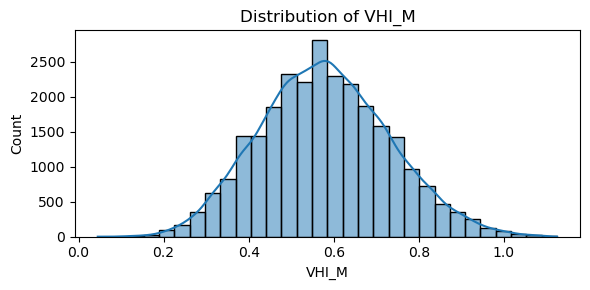

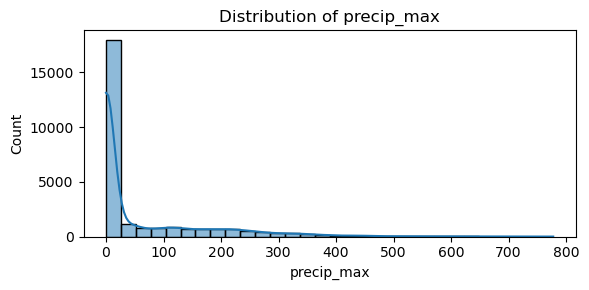

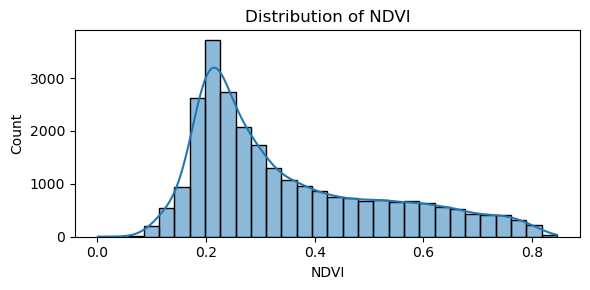

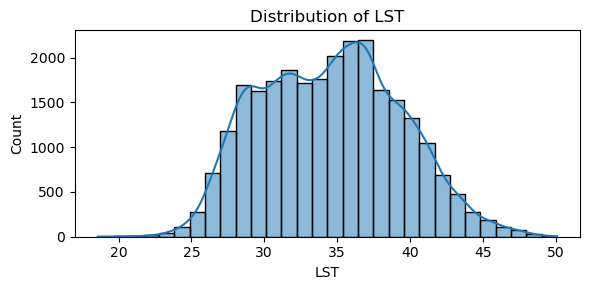

In [12]:
variables = ['VHI_M', 'precip_max', 'NDVI', 'LST']

for var in variables:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_cleaned[var], kde=True, bins=30)
    plt.title(f"Distribution of {var}")
    plt.tight_layout()
    plt.show()


## Aggregate the data seasonally 

In this section we will aggrgate the the `gdf` w.r.t the seasons and then plot them. Later, we will use these attributes for clustering. 

In [13]:
df_cleaned['precip_log'] = np.log1p(df_cleaned['precip_max'])
df_cleaned.drop(columns=['precip_max'], inplace=True)
seasonal_agg = df_cleaned.groupby(['fid','COMMUNE', 'season', 'year'])[
    ['VHI_M', 'precip_log', 'NDVI', 'LST']
].median().reset_index()
seasonal_agg

variable,fid,COMMUNE,season,year,VHI_M,precip_log,NDVI,LST
0,1,TAMBACOUNDA,Dry,2021,0.520,0.157608,0.192663,39.600000
1,1,TAMBACOUNDA,Dry,2022,0.625,0.117058,0.204502,38.753333
2,1,TAMBACOUNDA,Dry,2023,0.485,0.018668,0.201350,37.210000
3,1,TAMBACOUNDA,Dry,2024,0.490,0.435274,0.189750,37.440000
4,1,TAMBACOUNDA,Wet,2021,0.620,5.341242,0.405126,32.421573
...,...,...,...,...,...,...,...,...
4419,553,ZIGUINCHOR,Dry,2024,0.680,0.000000,0.252466,32.450000
4420,553,ZIGUINCHOR,Wet,2021,0.605,5.418181,0.411550,32.780000
4421,553,ZIGUINCHOR,Wet,2022,0.765,5.698172,0.392900,30.110000
4422,553,ZIGUINCHOR,Wet,2023,0.710,5.620157,0.412327,32.303325


In [14]:
# Reshape to wide format with multi-variable columns
seasonal_wide = seasonal_agg.pivot_table(
    index='fid',
    columns=['season', 'year'],
    values=['VHI_M', 'precip_log', 'NDVI', 'LST']
)
seasonal_wide

variable        LST                                                     \
season          Dry                                     Wet              
year           2021       2022       2023   2024       2021       2022   
fid                                                                      
1         39.600000  38.753333  37.210000  37.44  32.421573  33.230000   
2         40.070000  37.440000  37.583333  36.09  36.150000  31.630000   
3         32.300000  31.730000  32.070000  30.67  31.730000  31.960000   
4         42.090000  36.440000  39.145546  37.40  38.160000  35.450000   
5         40.900000  38.880000  37.610000  38.27  32.730000  31.730000   
..              ...        ...        ...    ...        ...        ...   
549       39.829912  39.650000  39.480772  38.31  36.915138  36.699743   
550       40.229084  39.754505  39.768500  38.69  36.529276  36.003693   
551       29.120000  30.690000  31.310000  29.66  32.610000  30.530000   
552       30.210000  31.800000  32.930000  30.86  33.130000  30.450000   
553       32.840000  32.885000  32.690000  32.45  32.780000  30.110000   

variable                            NDVI            ...  VHI_M         \
season                               Dry            ...    Wet          
year           2023       2024      2021      2022  ...   2023   2024   
fid                                                 ...                 
1         34.170000  32.010000  0.192663  0.204502  ...  0.605  0.385   
2         34.030000  31.769819  0.203983  0.197600  ...  0.855  0.655   
3         31.030000  30.010000  0.165300  0.168750  ...  0.535  0.540   
4         36.360000  33.290000  0.204850  0.195782  ...  0.610  0.585   
5         30.370000  28.860000  0.250575  0.276250  ...  0.560  0.735   
..              ...        ...       ...       ...  ...    ...    ...   
549       37.150530  33.790000  0.200933  0.198861  ...  0.660  0.655   
550       39.081892  33.728951  0.212655  0.202876  ...  0.595  0.680   
551       31.800000  30.650000  0.176800  0.187450  ...  0.560  0.585   
552       32.970000  31.020000  0.143950  0.139600  ...  0.595  0.635   
553       32.303325  26.950000  0.271725  0.272317  ...  0.710  0.675   

variable precip_log                                                    \
season          Dry                                     Wet             
year           2021      2022      2023      2024      2021      2022   
fid                                                                     
1          0.157608  0.117058  0.018668  0.435274  5.341242  4.998608   
2          0.000000  0.020210  0.001360  0.000000  4.705078  5.081048   
3          0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4          0.000000  0.045135  0.047617  0.000000  4.137547  4.920740   
5          0.000000  0.000000  0.089691  0.044863  5.177745  5.321357   
..              ...       ...       ...       ...       ...       ...   
549        0.004091  0.485820  0.325722  0.505094  3.771587  4.770688   
550        0.000000  0.632702  0.386974  0.641586  3.852466  4.909786   
551        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
552        0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
553        0.098411  0.024796  0.018684  0.000000  5.418181  5.698172   

variable                      
season                        
year          2023      2024  
fid                           
1         5.186658  5.274891  
2         4.929439  5.041465  
3         0.000000  0.000000  
4         4.450689  4.769836  
5         5.360491  5.403900  
..             ...       ...  
549       4.784261  4.395135  
550       4.878577  4.344799  
551       0.000000  0.000000  
552       0.000000  0.000000  
553       5.620157  5.834681  

[553 rows x 32 columns]

In [15]:
seasonal_wide.columns = [
    f"{season}_{var}_{year}" for var, season, year in seasonal_wide.columns
]
seasonal_wide = seasonal_wide.reset_index()
seasonal_wide.head()

,fid,Dry_LST_2021,Dry_LST_2022,Dry_LST_2023,Dry_LST_2024,Wet_LST_2021,Wet_LST_2022,Wet_LST_2023,Wet_LST_2024,Dry_NDVI_2021,...,Wet_VHI_M_2023,Wet_VHI_M_2024,Dry_precip_log_2021,Dry_precip_log_2022,Dry_precip_log_2023,Dry_precip_log_2024,Wet_precip_log_2021,Wet_precip_log_2022,Wet_precip_log_2023,Wet_precip_log_2024
0,1,39.60,38.753333,37.210000,37.44,32.421573,33.23,34.17,32.010000,0.192663,...,0.605,0.385,0.157608,0.117058,0.018668,0.435274,5.341242,4.998608,5.186658,5.274891
1,2,40.07,37.440000,37.583333,36.09,36.150000,31.63,34.03,31.769819,0.203983,...,0.855,0.655,0.000000,0.020210,0.001360,0.000000,4.705078,5.081048,4.929439,5.041465
2,3,32.30,31.730000,32.070000,30.67,31.730000,31.96,31.03,30.010000,0.165300,...,0.535,0.540,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4,42.09,36.440000,39.145546,37.40,38.160000,35.45,36.36,33.290000,0.204850,...,0.610,0.585,0.000000,0.045135,0.047617,0.000000,4.137547,4.920740,4.450689,4.769836
4,5,40.90,38.880000,37.610000,38.27,32.730000,31.73,30.37,28.860000,0.250575,...,0.560,0.735,0.000000,0.000000,0.089691,0.044863,5.177745,5.321357,5.360491,5.403900


## add geometry

In [16]:
# add aez based on fid to gdf aez csv
shapefile_path = r"D:\CDR_study_areas\study_areas\communes_new.shp"
gdf = gpd.read_file(shapefile_path)
gdf = gdf.rename(columns={'fid_1': 'fid'})
gdf = gdf[['fid', 'geometry', 'COMMUNE', 'REGION', 'LZCODE','LZNAMEEN','MAJORITY', 'aug_22', 'nov_dec_24', 'oct_24', 'recur' ]]
gdf = gdf.rename(columns={'LZNAMEEN': 'LZNAME', 'MAJORITY': 'DEM'})
gdf['LZCODE'] = gdf['LZCODE'].str.replace('SN', '', regex=False)
gdf
# aez = pd.read_csv(r"D:\CDR_study_areas\output\aez.csv")
# gdf = gdf.merge(aez[['fid', 'AEZclass']], on='fid', how='left')
# gdf

,fid,geometry,COMMUNE,REGION,LZCODE,LZNAME,DEM,aug_22,nov_dec_24,oct_24,recur
0,1.0,"POLYGON ((-13.64812 13.78878, -13.64785 13.788...",TAMBACOUNDA,TAMBACOUNDA,14,Rainfed Maize and Lumber,50,0.000000,0.000000e+00,0.000000,0
1,2.0,"POLYGON ((-12.45054 14.90702, -12.45081 14.906...",BAKEL,TAMBACOUNDA,03,Valley Rice and Remittances,28,0.000000,0.000000e+00,0.056679,1
2,3.0,"POLYGON ((-17.22586 14.71718, -17.22541 14.716...",BARGNY,DAKAR,01,The Niayes Gardening and Fishing,5,0.003143,0.000000e+00,0.000000,1
3,4.0,"POLYGON ((-13.16923 15.4729, -13.17825 15.4724...",KANEL,MATAM,04,Dieri Millet and Remittances,15,0.122824,7.662653e-02,0.121164,3
4,5.0,"POLYGON ((-12.14358 12.59416, -12.13871 12.591...",KEDOUGOU,KEDOUGOU,15,Rainfed Maize and Artisanal Gold Mining,115,0.000000,0.000000e+00,0.000758,1
...,...,...,...,...,...,...,...,...,...,...,...
548,549.0,"POLYGON ((-15.35661 16.03678, -15.34983 16.029...",TESSEKERE FORAGE,LOUGA,06,Sylvopatoral Livestock and Gathering,48,0.000000,0.000000e+00,0.000000,0
549,550.0,"POLYGON ((-15.29089 15.73521, -15.29033 15.732...",YANG YANG,LOUGA,06,Sylvopatoral Livestock and Gathering,49,0.000000,8.521420e-07,0.000000,1
550,551.0,"POLYGON ((-17.35422 14.80083, -17.35386 14.800...",YEUMBEUL NORD,DAKAR,00,Urban Area - Dakar,9,0.000000,0.000000e+00,0.000000,0
551,552.0,"POLYGON ((-17.36756 14.77359, -17.36749 14.773...",YEUMBEUL SUD,DAKAR,00,Urban Area - Dakar,11,0.000000,0.000000e+00,0.000000,0


In [17]:
wide_df_path = r"D:\CDR_study_areas\output\wide\wide_non_timeseries_data.csv"
wide_df = pd.read_csv(wide_df_path)
wide_df

,fid,REGION,COMMUNE,AEZclass,AEZclassname,popsum2021,popmean2021,popsum2022,popmean2022,popsum2023,...,popmean2024,Rainfed_percentage,Wetland_percentage,Bare_percentage,Impervious_percentage,Water_percentage,Irrigated_percentage,Forest_percentage,Shrubland_percentage,Grassland_percentage
0,1,TAMBACOUNDA,TAMBACOUNDA,2,Tropics lowland; semi-arid with soil/terrain l...,140566.540600,30.042005,141713.729200,30.287183,152955.139300,...,31.506370,0.003,0.000,0.001,0.344,0.000,0.000,0.002,0.481,0.169
1,2,TAMBACOUNDA,BAKEL,50,Land with severe soil/terrain limitations,20265.942750,21.332571,21103.194060,22.213888,22388.753140,...,22.227321,0.007,0.023,0.001,0.057,0.011,0.000,0.004,0.146,0.743
2,3,DAKAR,BARGNY,2,Tropics lowland; semi-arid with soil/terrain l...,71495.152140,53.917913,75394.331700,56.858470,79156.284510,...,58.766998,0.006,0.005,0.073,0.387,0.014,0.001,0.005,0.150,0.352
3,4,MATAM,KANEL,53,Desert/Arid climate,14971.092660,16.878346,15289.275110,17.121249,15662.579120,...,17.291040,0.018,0.220,0.009,0.066,0.000,0.000,0.000,0.017,0.658
4,5,KEDOUGOU,KEDOUGOU,50,Land with severe soil/terrain limitations,42552.968720,15.564363,43414.460930,15.769873,47194.379770,...,16.655478,0.001,0.014,0.000,0.203,0.000,0.000,0.251,0.524,0.006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,549,LOUGA,TESSEKERE FORAGE,53,Desert/Arid climate,15763.803960,1.107086,15389.979580,1.080226,15364.466740,...,1.139250,0.018,0.000,0.000,0.000,0.000,0.000,0.000,0.008,0.974
549,550,LOUGA,YANG YANG,53,Desert/Arid climate,6361.616788,1.310593,6442.566808,1.323996,6233.701516,...,1.332425,0.143,0.000,0.000,0.001,0.000,0.000,0.000,0.003,0.853
550,551,DAKAR,YEUMBEUL NORD,56,Dominantly built-up land,119860.913900,133.326934,120011.979000,133.494971,119435.090900,...,134.999166,0.001,0.005,0.011,0.746,0.000,0.001,0.038,0.033,0.160
551,552,DAKAR,YEUMBEUL SUD,56,Dominantly built-up land,44684.132330,169.258077,43860.937450,166.139915,43366.625000,...,164.802680,0.000,0.000,0.002,0.958,0.000,0.000,0.000,0.002,0.037


In [18]:
# combine all columns from 4th to gdf

gdf = gdf.merge(wide_df.iloc[:, 3:], left_index=True, right_index=True, how='left')
gdf = gdf.merge(seasonal_wide, on='fid', how='left')
gdf

,fid,geometry,COMMUNE,REGION,LZCODE,LZNAME,DEM,aug_22,nov_dec_24,oct_24,...,Wet_VHI_M_2023,Wet_VHI_M_2024,Dry_precip_log_2021,Dry_precip_log_2022,Dry_precip_log_2023,Dry_precip_log_2024,Wet_precip_log_2021,Wet_precip_log_2022,Wet_precip_log_2023,Wet_precip_log_2024
0,1.0,"POLYGON ((-13.64812 13.78878, -13.64785 13.788...",TAMBACOUNDA,TAMBACOUNDA,14,Rainfed Maize and Lumber,50,0.000000,0.000000e+00,0.000000,...,0.605,0.385,0.157608,0.117058,0.018668,0.435274,5.341242,4.998608,5.186658,5.274891
1,2.0,"POLYGON ((-12.45054 14.90702, -12.45081 14.906...",BAKEL,TAMBACOUNDA,03,Valley Rice and Remittances,28,0.000000,0.000000e+00,0.056679,...,0.855,0.655,0.000000,0.020210,0.001360,0.000000,4.705078,5.081048,4.929439,5.041465
2,3.0,"POLYGON ((-17.22586 14.71718, -17.22541 14.716...",BARGNY,DAKAR,01,The Niayes Gardening and Fishing,5,0.003143,0.000000e+00,0.000000,...,0.535,0.540,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4.0,"POLYGON ((-13.16923 15.4729, -13.17825 15.4724...",KANEL,MATAM,04,Dieri Millet and Remittances,15,0.122824,7.662653e-02,0.121164,...,0.610,0.585,0.000000,0.045135,0.047617,0.000000,4.137547,4.920740,4.450689,4.769836
4,5.0,"POLYGON ((-12.14358 12.59416, -12.13871 12.591...",KEDOUGOU,KEDOUGOU,15,Rainfed Maize and Artisanal Gold Mining,115,0.000000,0.000000e+00,0.000758,...,0.560,0.735,0.000000,0.000000,0.089691,0.044863,5.177745,5.321357,5.360491,5.403900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,549.0,"POLYGON ((-15.35661 16.03678, -15.34983 16.029...",TESSEKERE FORAGE,LOUGA,06,Sylvopatoral Livestock and Gathering,48,0.000000,0.000000e+00,0.000000,...,0.660,0.655,0.004091,0.485820,0.325722,0.505094,3.771587,4.770688,4.784261,4.395135
549,550.0,"POLYGON ((-15.29089 15.73521, -15.29033 15.732...",YANG YANG,LOUGA,06,Sylvopatoral Livestock and Gathering,49,0.000000,8.521420e-07,0.000000,...,0.595,0.680,0.000000,0.632702,0.386974,0.641586,3.852466,4.909786,4.878577,4.344799
550,551.0,"POLYGON ((-17.35422 14.80083, -17.35386 14.800...",YEUMBEUL NORD,DAKAR,00,Urban Area - Dakar,9,0.000000,0.000000e+00,0.000000,...,0.560,0.585,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
551,552.0,"POLYGON ((-17.36756 14.77359, -17.36749 14.773...",YEUMBEUL SUD,DAKAR,00,Urban Area - Dakar,11,0.000000,0.000000e+00,0.000000,...,0.595,0.635,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [19]:
def percentile_min_max_scaling(series, lower=2, upper=98):
    min_val = np.percentile(series.dropna(), lower)
    max_val = np.percentile(series.dropna(), upper)
    
    clipped = series.clip(lower=min_val, upper=max_val)
    
    scaled = (clipped - min_val) / (max_val - min_val)
    return scaled

columns_to_scale = ['Rainfed_percentage', 'Wetland_percentage', 'Bare_percentage',
                    'Impervious_percentage', 'Water_percentage', 'Irrigated_percentage',
                    'Shrubland_percentage', 'Forest_percentage', 'Grassland_percentage',
                    'Dry_LST_2021', 'Dry_LST_2022', 'Dry_LST_2023', 'Dry_LST_2024',
                    'Wet_LST_2021', 'Wet_LST_2022', 'Wet_LST_2023', 'Wet_LST_2024',
                    'Dry_NDVI_2021', 'Dry_NDVI_2022', 'Dry_NDVI_2023', 'Dry_NDVI_2024',
                    'Wet_NDVI_2021', 'Wet_NDVI_2022', 'Wet_NDVI_2023', 'Wet_NDVI_2024',
                    'Dry_VHI_M_2021', 'Dry_VHI_M_2022', 'Dry_VHI_M_2023', 'Dry_VHI_M_2024',
                    'Wet_VHI_M_2021', 'Wet_VHI_M_2022', 'Wet_VHI_M_2023', 'Wet_VHI_M_2024',
                    'Dry_precip_log_2021', 'Dry_precip_log_2022',  'Dry_precip_log_2023', 'Dry_precip_log_2024',
                    'Wet_precip_log_2021', 'Wet_precip_log_2022', 'Wet_precip_log_2023', 'Wet_precip_log_2024',
                    ]

for col in columns_to_scale:
    if gdf[col].dtype in ['float64', 'int64']:  # Only scale numeric columns
        gdf[f"{col}_scaled"] = percentile_min_max_scaling(gdf[col])
gdf
gdf.drop(columns=columns_to_scale, inplace=True)  # Drop original columns after scaling
gdf

,fid,geometry,COMMUNE,REGION,LZCODE,LZNAME,DEM,aug_22,nov_dec_24,oct_24,...,Wet_VHI_M_2023_scaled,Wet_VHI_M_2024_scaled,Dry_precip_log_2021_scaled,Dry_precip_log_2022_scaled,Dry_precip_log_2023_scaled,Dry_precip_log_2024_scaled,Wet_precip_log_2021_scaled,Wet_precip_log_2022_scaled,Wet_precip_log_2023_scaled,Wet_precip_log_2024_scaled
0,1.0,"POLYGON ((-13.64812 13.78878, -13.64785 13.788...",TAMBACOUNDA,TAMBACOUNDA,14,Rainfed Maize and Lumber,50,0.000000,0.000000e+00,0.000000,...,0.455941,0.000000,0.464361,0.241222,0.036039,0.824793,0.940413,0.839592,0.896804,0.894627
1,2.0,"POLYGON ((-12.45054 14.90702, -12.45081 14.906...",BAKEL,TAMBACOUNDA,03,Valley Rice and Remittances,28,0.000000,0.000000e+00,0.056679,...,1.000000,0.578389,0.000000,0.041646,0.002626,0.000000,0.828406,0.853439,0.852330,0.855038
2,3.0,"POLYGON ((-17.22586 14.71718, -17.22541 14.716...",BARGNY,DAKAR,01,The Niayes Gardening and Fishing,5,0.003143,0.000000e+00,0.000000,...,0.282673,0.301013,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4.0,"POLYGON ((-13.16923 15.4729, -13.17825 15.4724...",KANEL,MATAM,04,Dieri Millet and Remittances,15,0.122824,7.662653e-02,0.121164,...,0.468317,0.409551,0.000000,0.093010,0.091926,0.000000,0.728483,0.826513,0.769551,0.808970
4,5.0,"POLYGON ((-12.14358 12.59416, -12.13871 12.591...",KEDOUGOU,KEDOUGOU,15,Rainfed Maize and Artisanal Gold Mining,115,0.000000,0.000000e+00,0.000758,...,0.344554,0.771346,0.000000,0.000000,0.173151,0.085010,0.911627,0.893802,0.926861,0.916508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,549.0,"POLYGON ((-15.35661 16.03678, -15.34983 16.029...",TESSEKERE FORAGE,LOUGA,06,Sylvopatoral Livestock and Gathering,48,0.000000,0.000000e+00,0.000000,...,0.592079,0.578389,0.012053,1.000000,0.628813,0.957095,0.664050,0.801309,0.827227,0.745420
549,550.0,"POLYGON ((-15.29089 15.73521, -15.29033 15.732...",YANG YANG,LOUGA,06,Sylvopatoral Livestock and Gathering,49,0.000000,8.521420e-07,0.000000,...,0.431188,0.638688,0.000000,1.000000,0.747062,1.000000,0.678290,0.824673,0.843535,0.736883
550,551.0,"POLYGON ((-17.35422 14.80083, -17.35386 14.800...",YEUMBEUL NORD,DAKAR,00,Urban Area - Dakar,9,0.000000,0.000000e+00,0.000000,...,0.344554,0.409551,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
551,552.0,"POLYGON ((-17.36756 14.77359, -17.36749 14.773...",YEUMBEUL SUD,DAKAR,00,Urban Area - Dakar,11,0.000000,0.000000e+00,0.000000,...,0.431188,0.530150,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Plot time series

In [20]:
# pd_aez = pd.read_csv(r"D:\CDR_study_areas\output\wide\aez.csv")
# pd_ts =df_cleaned.merge(pd_aez, on='fid', how='left')
# pd_ts


In [21]:
# def plot_multi_variable_time_series(gdf_ts, random_seed=123):
#     """
#     Create 4 subplots for 4 variables, each showing time series for one randomly 
#     selected commune from each AEZ class (8 communes total per plot).
#     """
#     np.random.seed(random_seed)
    
#     # Variables to plot
#     variables = ['VHI_M_scaled', 'LST_scaled', 'NDVI', 'precip_log_scaled']
#     var_names = ['Vegetation Health Index-Scaled', 'Land Surface Temperature-Scaled', 'NDVI',  'Precipitation-Scaled',]
    
#     # Get unique AEZ classes
#     aez_classes = gdf_ts['AEZclass'].unique()
#     n_aez = len(aez_classes)
    
#     # Select one random commune from each AEZ class
#     selected_communes = []
#     for aez in aez_classes:
#         aez_communes = gdf_ts[gdf_ts['AEZclass'] == aez]['fid'].unique()
#         if len(aez_communes) > 0:
#             selected_commune = np.random.choice(aez_communes)
#             selected_communes.append(selected_commune)
    
#     print(f"Selected {len(selected_communes)} communes from {n_aez} AEZ classes")
    
#     # Filter data for selected communes
#     plot_data = gdf_ts[gdf_ts['fid'].isin(selected_communes)].copy()
#     plot_data = plot_data.sort_values(['fid', 'date'])
    
#     # Create color map for AEZ classes
#     colors = plt.cm.brg(np.linspace(0, 1, n_aez))
#     aez_color_map = dict(zip(aez_classes, colors))
    
#     # Create subplots
#     fig, axes = plt.subplots(2, 2, figsize=(16, 12))
#     axes = axes.flatten()
    
#     for i, (var, var_name) in enumerate(zip(variables, var_names)):
#         ax = axes[i]
        
#         # Plot each commune
#         for commune_id in selected_communes:
#             commune_data = plot_data[plot_data['fid'] == commune_id]
#             if not commune_data.empty:
#                 aez_class = commune_data['AEZclass'].iloc[0]
#                 color = aez_color_map[aez_class]
                
#                 # Plot the time series
#                 ax.plot(commune_data['date'], commune_data[var], 
#                        color=color, alpha=0.8, linewidth=1.5,
#                        label=f'AEZ: {aez_class} (Commune {commune_id})')
        
#         # Customize subplot
#         ax.set_title(f'{var_name}', fontsize=12, fontweight='bold')
#         ax.set_xlabel('Date', fontsize=10)
#         ax.set_ylabel('Z-score', fontsize=10)
#         ax.grid(True, alpha=0.3)
        
#         # Set x-axis to show fewer date ticks
#         ax.tick_params(axis='x', rotation=45, labelsize=8)
#         dates = plot_data['date'].unique()
#         n_ticks = min(8, len(dates))  # Show max 8 date ticks
#         tick_indices = np.linspace(0, len(dates)-1, n_ticks, dtype=int)
#         ax.set_xticks([dates[i] for i in tick_indices])
        
#         # Add legend only for first subplot to avoid clutter
#         if i == 0:
#             ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
#     plt.tight_layout()
#     plt.show()
    
#     # Print summary
#     print(f"\nPlotted time series for {len(selected_communes)} communes:")
#     for commune_id in selected_communes:
#         commune_info = plot_data[plot_data['fid'] == commune_id]
#         if not commune_info.empty:
#             aez_class = commune_info['AEZclass'].iloc[0]
#             print(f"  Commune {commune_id}: {aez_class}")


# plot_multi_variable_time_series(pd_ts)

## Plot maps

In [29]:
%matplotlib inline


def plot_interactive_maps(year, season):
    """
    Create 4 subplots showing maps for the 4 variables (LST, VHI_M, precip_log, NDVI)
    for the selected year and season.
    """
    # Clear any existing plots
    plt.close('all')
    
    # Define variables and their display names
    variables = ['LST', 'VHI_M', 'precip_log', 'NDVI']
    var_names = ['Land Surface Temperature', 'Vegetation Health Index', 'Precipitation Log', 'NDVI']
    
    # Define color schemes for each variable
    color_schemes = {
        'LST': 'Reds',           
        'VHI_M': 'RdYlGn',       
        'precip_log': 'Blues',   
        'NDVI': 'Greens'         
    }
    
    # Create column names for the selected year and season
    columns_to_plot = []
    for var in variables:
        col_name = f"{season}_{var}_{year}_scaled"
        if col_name in gdf.columns:
            columns_to_plot.append((var, col_name))
        else:
            print(f"Warning: Column {col_name} not found in data")
    
    if not columns_to_plot:
        print(f"No data found for {season} season in {year}")
        return
    
    # Create subplots - SINGLE FIGURE ONLY
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for i, (var, col_name) in enumerate(columns_to_plot):
        if i >= 4:
            break
            
        ax = axes[i]
        plot_data = gdf[gdf[col_name].notna()].copy()
    
        if plot_data.empty:
            ax.text(0.5, 0.5, f'No data for {var}', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=12)
            ax.set_title(f'{var_names[i]} - {season} {year}')
            continue
        
        # Plot the map
        plot_data.plot(column=col_name, 
                      ax=ax, 
                      cmap=color_schemes[var],
                      legend=True,
                      legend_kwds={'shrink': 0.8, 'aspect': 20},
                      edgecolor='black',
                      linewidth=0.5,
                      alpha=0.8)
        
        # Customize the subplot
        ax.set_title(f'{var_names[i]} - {season} {year}', fontsize=14, fontweight='bold', pad=20)
        ax.set_axis_off()
        
        # Add statistics
        data_values = plot_data[col_name]
        stats_text = f'Min: {data_values.min():.2f}\nMax: {data_values.max():.2f}\nMedian: {data_values.median():.2f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
               fontsize=9)
    
    # Hide unused subplots
    for j in range(len(columns_to_plot), 4):
        axes[j].set_visible(False)
    
    plt.suptitle(f'Environmental Variables - {season} Season {year}', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()
    
    # Print summary information
    print(f"\nDisplayed maps for {season} season {year}:")
    for var, col_name in columns_to_plot:
        if col_name in gdf.columns:
            non_null_count = gdf[col_name].notna().sum()
            print(f"  {var}: {non_null_count} communes with data")

# Create the interactive widget - THIS SHOULD BE THE ONLY CALL
interact(plot_interactive_maps, 
         year=widgets.Dropdown(options=[2021, 2022, 2023, 2024], value=2021, description='Year'),
         season=widgets.Dropdown(options=['Dry', 'Wet'], value='Dry', description='Season'))

interactive(children=(Dropdown(description='Year', options=(2021, 2022, 2023, 2024), value=2021), Dropdown(des…

<function __main__.plot_interactive_maps(year, season)>

In [22]:
# # # export gdf_agg to shapefile
output_path = r"D:\CDR_study_areas\output\gdf_aggregate_new.geojson"
# drop geometry for CSV export
# gdf.drop(columns='geometry', inplace=True)
gdf.to_file(output_path, index=False)
print(f"Exported gdf_agg to {output_path} without geometry column")

Exported gdf_agg to D:\CDR_study_areas\output\gdf_aggregate_new.geojson without geometry column
